Name :- Sandesh Arun Mohite

Roll_No :- 23

Division :- T.Y(AIML)-A


# Part-1: Multiclass Classification using Logistic Regression

## Experiment Objective
To understand and implement **Logistic Regression for Multiclass Classification** using a **simple manually created dataset**.

### Example Use Case
Predict **Student Performance Level** (Low, Medium, High) based on:
- Study Hours
- Attendance Percentage



## Step 1: Import Required Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report



## Step 2: Create a Simple Multiclass Dataset
Target Variable:
- 0 → Low Performance
- 1 → Medium Performance
- 2 → High Performance


In [2]:

data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,9,10],
    'Attendance': [50,55,60,65,70,75,80,85,90,95],
    'Performance': [0,0,0,1,1,1,2,2,2,2]
}

df = pd.DataFrame(data)
df


,Study_Hours,Attendance,Performance
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,1
4,5,70,1
5,6,75,1
6,7,80,2
7,8,85,2
8,9,90,2
9,10,95,2



## Step 3: Explore the Dataset


In [3]:
df.shape

(10, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Performance  10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [5]:
df.describe()

,Study_Hours,Attendance,Performance
count,10.00000,10.000000,10.000000
mean,5.50000,72.500000,1.100000
std,3.02765,15.138252,0.875595
min,1.00000,50.000000,0.000000
25%,3.25000,61.250000,0.250000
50%,5.50000,72.500000,1.000000
75%,7.75000,83.750000,2.000000
max,10.00000,95.000000,2.000000



## Step 4: Split Features and Target


In [6]:
X = df[['Study_Hours', 'Attendance']]
y = df['Performance']


## Step 5: Train-Test Split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 6: Create and Train Logistic Regression Model


In [8]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')


## Step 7: Model Prediction and Evaluation


In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2




## Step 8: Visualization


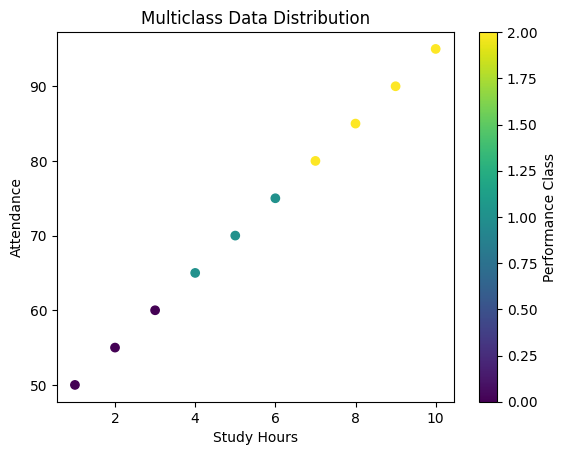

In [10]:
plt.scatter(df['Study_Hours'], df['Attendance'], c=df['Performance'], cmap='viridis')
plt.xlabel('Study Hours')
plt.ylabel('Attendance')
plt.title('Multiclass Data Distribution')
plt.colorbar(label='Performance Class')
plt.show()


## Step 9: Prediction Using User Input


In [11]:
study_hours = float(input("Enter study hours: "))
attendance = float(input("Enter attendance percentage: "))

new_data = [[study_hours, attendance]]
prediction = model.predict(new_data)

labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Predicted Performance Level:", labels[prediction[0]])

Enter study hours: 15
Enter attendance percentage: 80
Predicted Performance Level: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



## Conclusion
Logistic Regression can be extended for multiclass classification using the multinomial approach.



# Part-2: Multiclass Classification using Logistic Regression (Iris Dataset)

## Problem Statement
The Iris dataset contains measurements of flowers (sepal length, sepal width, petal length, petal width).
The task is to classify a flower into one of three species:
- Setosa
- Versicolor
- Virginica

This is a **multiclass classification problem** solved using **Logistic Regression (Softmax)**.


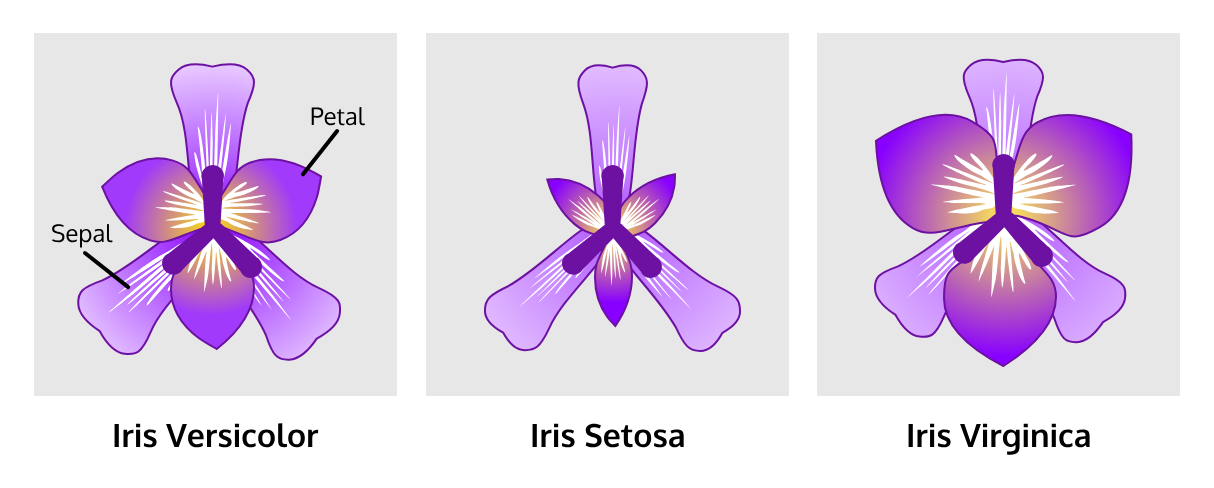

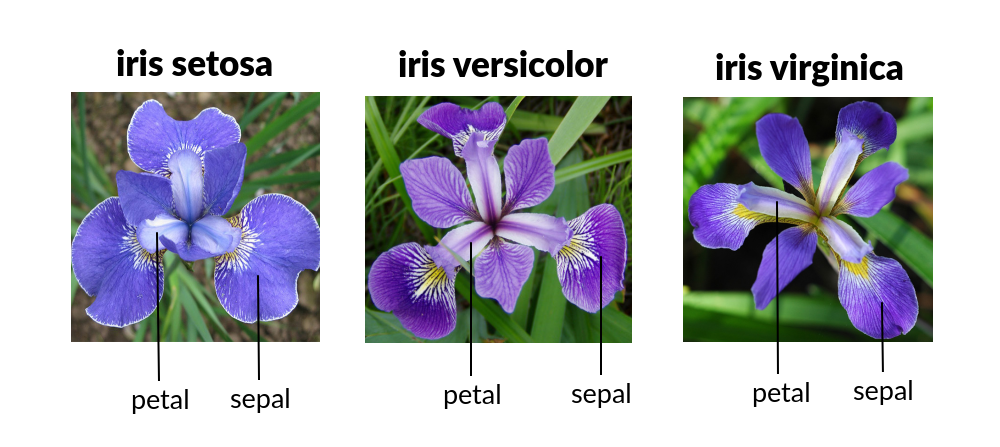

In [12]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



## Step 1: Load the Iris Dataset
The Iris dataset is a built-in dataset available in scikit-learn.


In [13]:
# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



## Step 2: Dataset Information


In [14]:
df.shape

(150, 5)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



## Step 3: Define Features and Target


In [17]:
X = df.iloc[:, :-1]   # all feature columns
y = df['species']    # target column


## Step 4: Train-Test Split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 5: Train Logistic Regression Model (Multiclass)


In [19]:
model = LogisticRegression(multi_class='multinomial', max_iter=200)
model.fit(X_train, y_train)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial')


## Step 6: Model Evaluation


In [20]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 7: Visualization of Multiclass Data Distribution

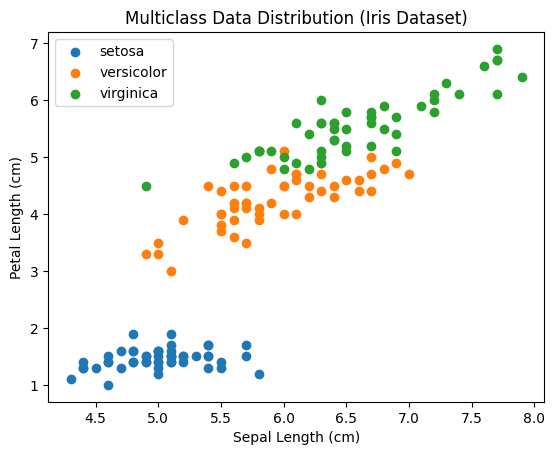

In [21]:
# Feature names for visualization
x_feature = 'sepal length (cm)'
y_feature = 'petal length (cm)'

# Plot each class separately
for class_value in range(3):
    plt.scatter(
        X.loc[y == class_value, x_feature],
        X.loc[y == class_value, y_feature],
        label=iris.target_names[class_value]
    )

# Labels and title
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Multiclass Data Distribution (Iris Dataset)")
plt.legend()
plt.show()


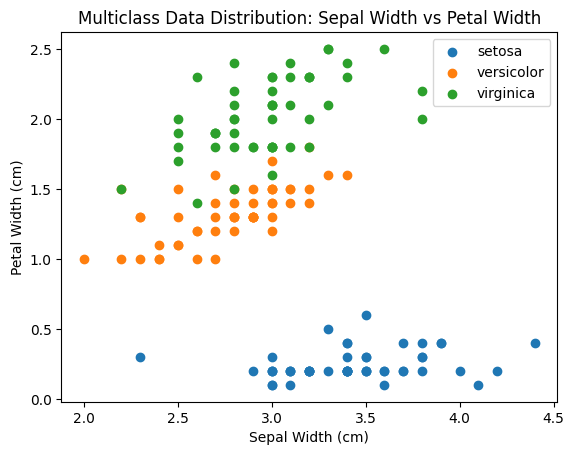

In [22]:
# Feature names
x_feature = 'sepal width (cm)'
y_feature = 'petal width (cm)'

# Plot data for each class
for class_value in range(3):
    plt.scatter(
        X.loc[y == class_value, x_feature],
        X.loc[y == class_value, y_feature],
        label=iris.target_names[class_value]
    )

# Plot formatting
plt.xlabel("Sepal Width (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Multiclass Data Distribution: Sepal Width vs Petal Width")
plt.legend()
plt.show()



## Step 8: Prediction Using User Input


In [23]:
# Take user input
sepal_length = float(input("Enter Sepal Length:4.3 to 7.9 cm"))
sepal_width  = float(input("Enter Sepal Width:2.0 to 4.4 cm "))
petal_length = float(input("Enter Petal Length:1.0 to 6.9 cm "))
petal_width  = float(input("Enter Petal Width:0.1 to 2.5 cm "))

# Create input array
new_flower = [[sepal_length, sepal_width, petal_length, petal_width]]

# Predict
prediction = model.predict(new_flower)

# Output result
print("Predicted Species:", iris.target_names[prediction[0]])


Enter Sepal Length:4.3 to 7.9 cm5.0
Enter Sepal Width:2.0 to 4.4 cm 3.0
Enter Petal Length:1.0 to 6.9 cm 2.0
Enter Petal Width:0.1 to 2.5 cm 2.0
Predicted Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [24]:
import pickle

In [25]:
pickle.dump(model,open('MCModel.pkl','wb'))

**Flask Code**

Save this file with 'app.py'

In [26]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load Trained Model
model = pickle.load(open("MCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read input values
    sepal_length = float(request.form['sepal_length'])
    sepal_width = float(request.form['sepal_width'])
    petal_length = float(request.form['petal_length'])
    petal_width = float(request.form['petal_width'])

    # Prediction
    prediction = model.predict([[sepal_length,
                                 sepal_width,
                                 petal_length,
                                 petal_width]])

    # Convert class number into species name
    if prediction[0] == 0:
        flower = "Iris Setosa"

    elif prediction[0] == 1:
        flower = "Iris Versicolor"

    else:
        flower = "Iris Virginica"

    return render_template(
        "index.html",
        prediction_text=f"Predicted Species : {flower}"
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file with 'index.html'

In [27]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Iris Flower Species Predictor</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{

    background:#eef5ff;
    display:flex;
    justify-content:center;
    align-items:center;
    height:100vh;

}

.container{

    width:480px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 10px 25px rgba(0,0,0,.2);

}

h1{

    text-align:center;
    color:#1565c0;

}

h3{

    text-align:center;
    color:#555;
    margin-top:8px;
    margin-bottom:25px;

}

label{

    font-weight:bold;
    display:block;
    margin-top:12px;
    margin-bottom:6px;

}

input{

    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;

}

button{

    width:100%;
    margin-top:25px;
    padding:13px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;

}

button:hover{

    background:#0d47a1;

}

.result{

    margin-top:25px;
    background:#e8f5e9;
    padding:18px;
    border-radius:8px;
    text-align:center;
    color:green;
    font-size:22px;
    font-weight:bold;

}

footer{

    text-align:center;
    margin-top:20px;
    color:#777;
    font-size:13px;

}

</style>

</head>

<body>

<div class="container">

<h1>Iris Flower Predictor</h1>

<h3>Multiclass Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Sepal Length (cm)</label>

<input
type="number"
name="sepal_length"
step="0.1"
placeholder="Enter Sepal Length:4.3 to 7.9 cm"
required>

<label>Sepal Width (cm)</label>

<input
type="number"
name="sepal_width"
step="0.1"
placeholder="Enter Sepal Width:2.0 to 4.4 cm"
required>

<label>Petal Length (cm)</label>

<input
type="number"
name="petal_length"
step="0.1"
placeholder="Enter Petal Length:1.0 to 6.9 cm"
required>

<label>Petal Width (cm)</label>

<input
type="number"
name="petal_width"
step="0.1"
placeholder="Enter Petal Width:0.1 to 2.5 cm"
required>

<button type="submit">

Predict Flower Species

</button>

</form>

{% if prediction_text %}

<div class="result">

{{ prediction_text }}

</div>

{% endif %}

<footer>

By Dr. Sachin Balawant Takmare

</footer>

</div>

</body>

</html>

SyntaxError: invalid decimal literal (1922590440.py, line 26)